Number of training points: 50
Number of test points: 50

For K=1:
Confusion matrix:
[[27  0]
 [ 0 23]]
Accuracy: 1.0000

For K=2:
Confusion matrix:
[[27  0]
 [ 0 23]]
Accuracy: 1.0000

For K=3:
Confusion matrix:
[[27  0]
 [ 0 23]]
Accuracy: 1.0000

For K=4:
Confusion matrix:
[[27  0]
 [ 0 23]]
Accuracy: 1.0000

For K=5:
Confusion matrix:
[[27  0]
 [ 0 23]]
Accuracy: 1.0000

For K=20:
Confusion matrix:
[[25  2]
 [ 0 23]]
Accuracy: 0.9600

For K=30:
Confusion matrix:
[[25  2]
 [ 0 23]]
Accuracy: 0.9600



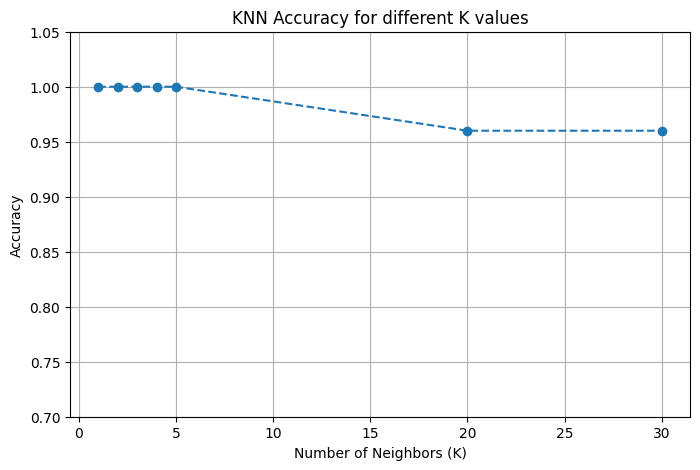

In [3]:
import random as rd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Generate data
X_list = [rd.random() for i in range(100)]
Y_list = [0] * len(X_list)

for i in range(len(X_list)):
    if X_list[i] <= 0.5:          # ← This line must be indented
        Y_list[i] = "Class1"
    else:
        Y_list[i] = "Class2"

X = np.array(X_list).reshape(-1, 1)   # KNN needs 2D array
Y = np.array(Y_list)

# Split the data (first 50 train, last 50 test because shuffle=False)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.5, train_size=0.5, shuffle=False, stratify=None
)

print(f'Number of training points: {len(X_train)}')
print(f'Number of test points: {len(X_test)}\n')

# Try different K values
K = [1, 2, 3, 4, 5, 20, 30]
acc = []
cm_list = []

for i in K:
    classify = KNeighborsClassifier(n_neighbors=i)
    classify.fit(X_train, Y_train)
    Y_predict = classify.predict(X_test)
    
    cm_i = confusion_matrix(Y_test, Y_predict)
    acc_i = accuracy_score(Y_test, Y_predict)
    
    cm_list.append(cm_i)
    acc.append(acc_i)
    
    print(f'For K={i}:')
    print('Confusion matrix:')
    print(cm_i)
    print(f'Accuracy: {acc_i:.4f}\n')

# Plot accuracy vs K
plt.figure(figsize=(8, 5))
plt.plot(K, acc, marker='o', linestyle='--')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for different K values')
plt.ylim(0.7, 1.05)
plt.grid(True)
plt.show()

--- k-Nearest Neighbors Classification ---
Training dataset: First 50 points labeled based on the rule (x <= 0.5 -> Class1, x > 0.5 -> Class2)
Testing dataset: Remaining 50 points to be classified

Results for k = 1:
Point x51 (value: 0.3130) is classified as Class1
Point x52 (value: 0.7381) is classified as Class2
Point x53 (value: 0.7254) is classified as Class2
Point x54 (value: 0.7898) is classified as Class2
Point x55 (value: 0.9162) is classified as Class2
Point x56 (value: 0.1405) is classified as Class1
Point x57 (value: 0.6167) is classified as Class2
Point x58 (value: 0.6872) is classified as Class2
Point x59 (value: 0.1811) is classified as Class1
Point x60 (value: 0.8057) is classified as Class2
Point x61 (value: 0.7808) is classified as Class2
Point x62 (value: 0.1449) is classified as Class1
Point x63 (value: 0.1166) is classified as Class1
Point x64 (value: 0.5564) is classified as Class2
Point x65 (value: 0.4073) is classified as Class1
Point x66 (value: 0.3497) is clas

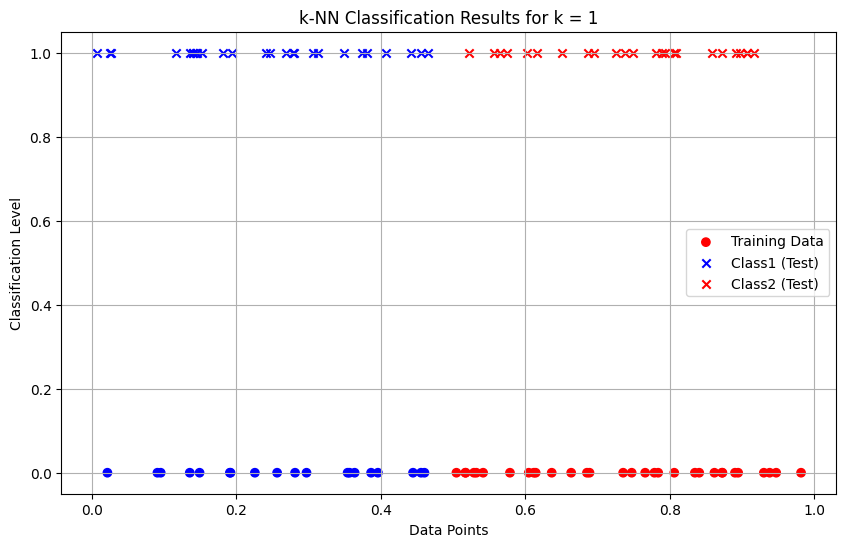

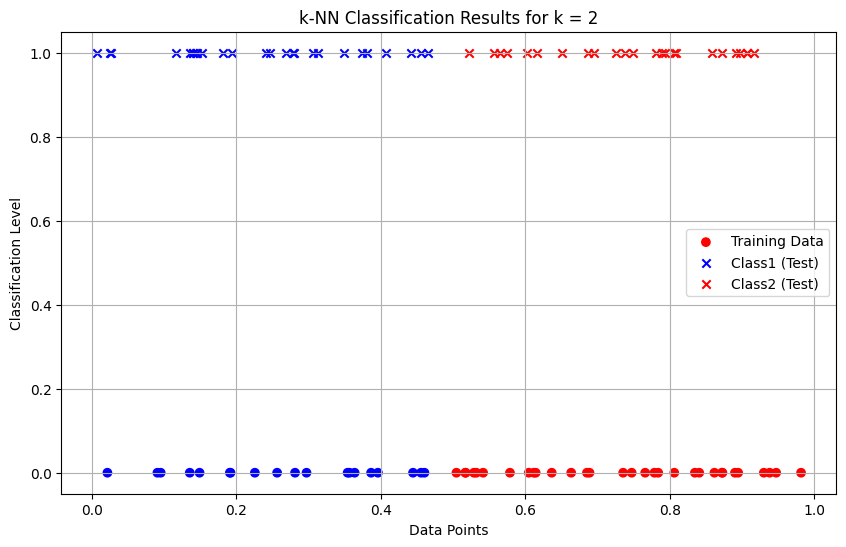

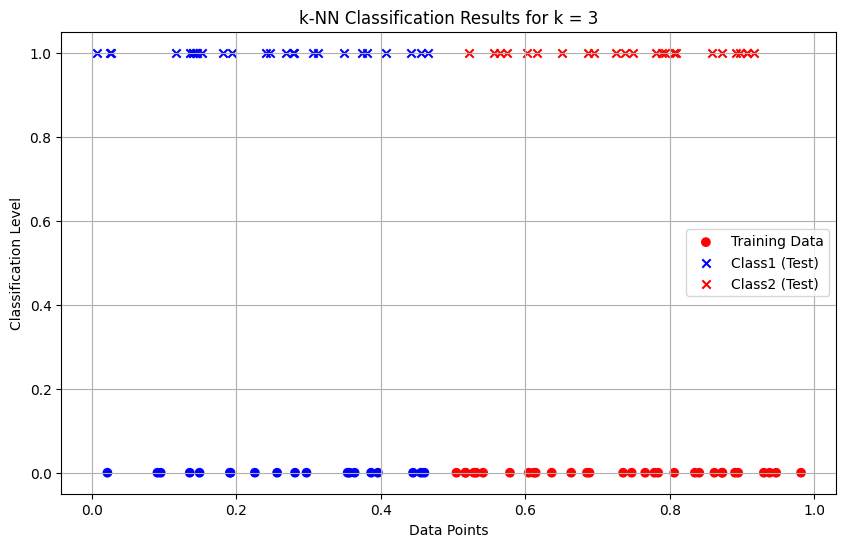

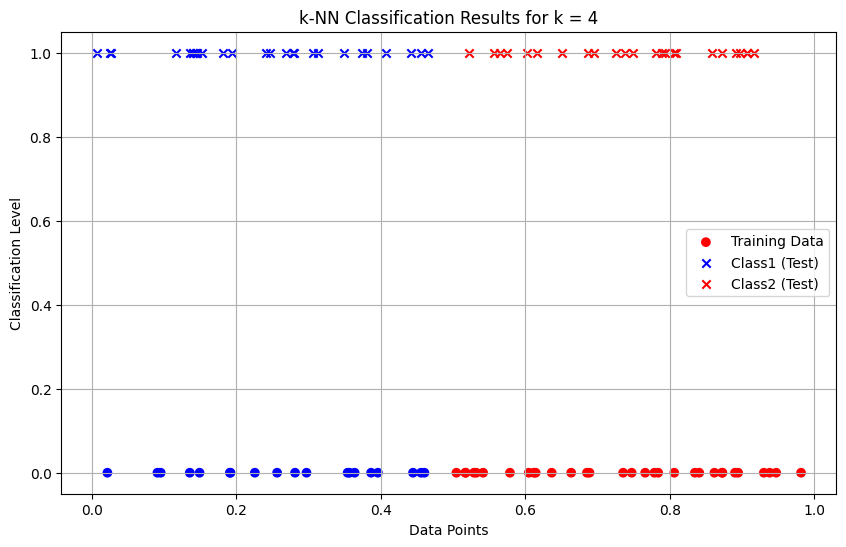

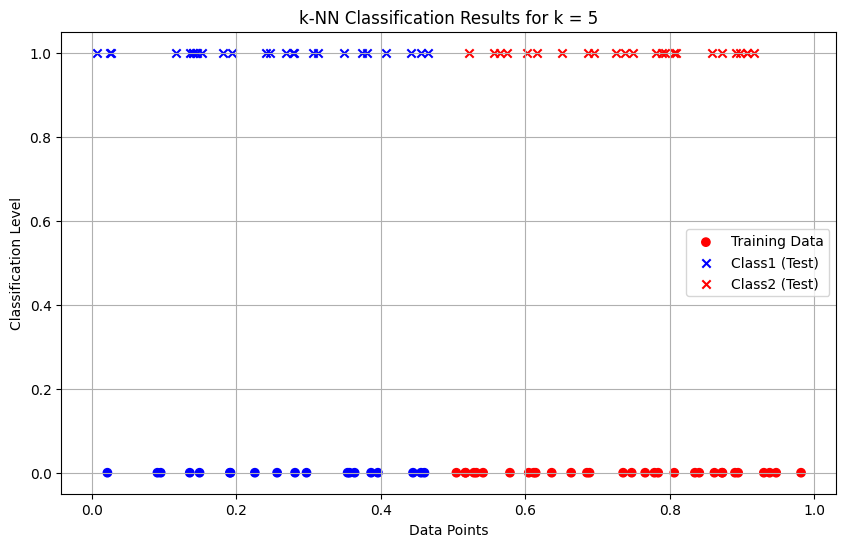

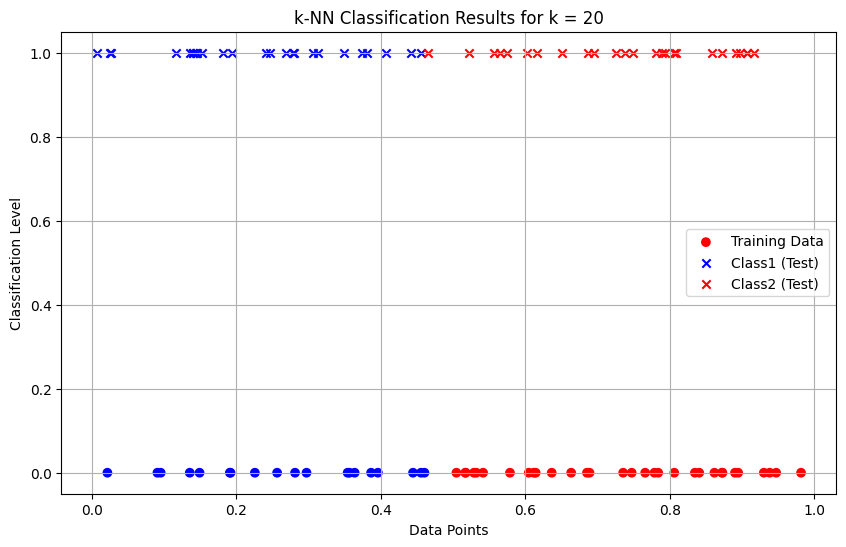

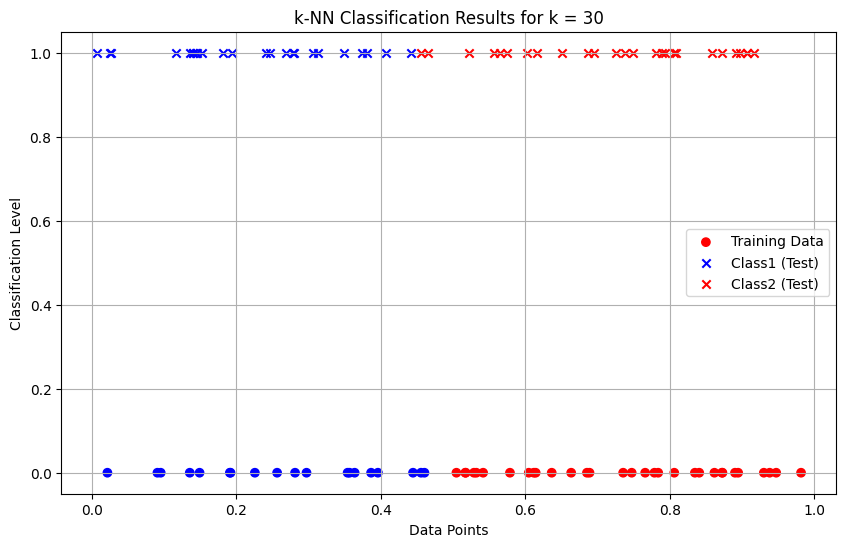

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

data = np.random.rand(100)

labels = ["Class1" if x <= 0.5 else "Class2" for x in data[:50]]


def euclidean_distance(x1, x2):
    return abs(x1 - x2)


def knn_classifier(train_data, train_labels, test_point, k):
    distances = [(euclidean_distance(test_point, train_data[i]), train_labels[i]) for i in range(len(train_data))]

    distances.sort(key=lambda x: x[0])
    k_nearest_neighbors = distances[:k]

    k_nearest_labels = [label for _, label in k_nearest_neighbors]

    return Counter(k_nearest_labels).most_common(1)[0][0]


train_data = data[:50]
train_labels = labels

test_data = data[50:]

k_values = [1, 2, 3, 4, 5, 20, 30]

print("--- k-Nearest Neighbors Classification ---")
print("Training dataset: First 50 points labeled based on the rule (x <= 0.5 -> Class1, x > 0.5 -> Class2)")
print("Testing dataset: Remaining 50 points to be classified\n")

results = {}

for k in k_values:
    print(f"Results for k = {k}:")
    classified_labels = [knn_classifier(train_data, train_labels, test_point, k) for test_point in test_data]
    results[k] = classified_labels

    for i, label in enumerate(classified_labels, start=51):
        print(f"Point x{i} (value: {test_data[i - 51]:.4f}) is classified as {label}")
    print("\n")

print("Classification complete.\n")

for k in k_values:
    classified_labels = results[k]
    class1_points = [test_data[i] for i in range(len(test_data)) if classified_labels[i] == "Class1"]
    class2_points = [test_data[i] for i in range(len(test_data)) if classified_labels[i] == "Class2"]

    plt.figure(figsize=(10, 6))
    plt.scatter(train_data, [0] * len(train_data), c=["blue" if label == "Class1" else "red" for label in train_labels],
                label="Training Data", marker="o")
    plt.scatter(class1_points, [1] * len(class1_points), c="blue", label="Class1 (Test)", marker="x")
    plt.scatter(class2_points, [1] * len(class2_points), c="red", label="Class2 (Test)", marker="x")

    plt.title(f"k-NN Classification Results for k = {k}")
    plt.xlabel("Data Points")
    plt.ylabel("Classification Level")
    plt.legend()
    plt.grid(True)
    plt.show()